# Notebook 16 — Baseline Hurdle Model

This notebook estimates the baseline hurdle model for journalist killings using the final monadic panel.This notebook uses the baseline feature list defined in Notebook 14 and does not add network predictors.

Model interpretation cautions:
- Iraq and Syria may dominate ODA coefficients; treat this as a possible crisis-aid confound rather than evidence of structural dependency.
- Arms effects may be driven by a small number of country-years. Prior diagnostics showed high concentration (Gini about 0.777) and density below 1%.
- ODA and economic dependency overlap is non-trivial (Jaccard about 0.55), so VIF is checked before interpreting coefficients.
- Colonial and arms PageRank are near-uniform and may add noise in the network model; this is mainly a Notebook 17 concern.
- Econ PageRank is uniform for 1993-1995 in the final panel because of the ECI coverage gap and 1-year lag offset. Document this if network features are inspected.
- Lagged predictors remove rows with missing values; exact sample loss is calculated below.
- The econ-mean robustness variant has materially smaller coverage because of about 35.6% missingness and should be interpreted separately.

In [12]:
from pathlib import Path
import pickle
import warnings

import numpy as np
import pandas as pd
import statsmodels.api as sm
from statsmodels.discrete.discrete_model import Logit, NegativeBinomial
from statsmodels.stats.outliers_influence import variance_inflation_factor

warnings.filterwarnings('default')
pd.set_option('display.max_columns', 120)
pd.set_option('display.width', 160)

DATA_PATH = Path('..') / 'data' / 'merged' / 'panel_final_1992_2024.csv'
MODELS_DIR = Path('..') / 'outputs' / 'models'
RESULTS_DIR = Path('..') / 'outputs' / 'results'

MODELS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print(f'Data path: {DATA_PATH}')
print(f'Model output dir: {MODELS_DIR}')
print(f'Results output dir: {RESULTS_DIR}')

Data path: ../data/merged/panel_final_1992_2024.csv
Model output dir: ../outputs/models
Results output dir: ../outputs/results


## Load and Inspect Final Panel

In [13]:
panel = pd.read_csv(DATA_PATH)

print(f'Panel shape: {panel.shape[0]:,} rows x {panel.shape[1]:,} columns')
display(panel.head())

column_inventory = pd.DataFrame({
    'column': panel.columns,
    'dtype': [panel[c].dtype for c in panel.columns],
    'missing_n': [panel[c].isna().sum() for c in panel.columns],
    'missing_pct': [panel[c].isna().mean() * 100 for c in panel.columns],
})

display(column_inventory.sort_values(['missing_pct', 'column'], ascending=[False, True]).head(40))
column_inventory.to_csv(RESULTS_DIR / 'nb16_panel_column_missingness.csv', index=False)
print('Saved: outputs/results/nb16_panel_column_missingness.csv')

Panel shape: 6,358 rows x 38 columns


,recipient_iso3,year,arms_tiv_total,oda_total,econ_neocol_score_total,colonial_tie_flag,journalist_killings,gdp_per_capita,gdp_per_capita_log,population,population_log,armed_conflict,conflict_intensity,arms_tiv_in_strength_lag1,arms_tiv_out_strength_lag1,arms_tiv_dependency_balance_lag1,arms_tiv_in_concentration_lag1,arms_tiv_pagerank_lag1,bilateral_oda_in_strength_lag1,bilateral_oda_out_strength_lag1,bilateral_oda_dependency_balance_lag1,bilateral_oda_in_concentration_lag1,bilateral_oda_pagerank_lag1,colonial_tie_in_strength_lag1,colonial_tie_out_strength_lag1,colonial_tie_dependency_balance_lag1,colonial_tie_in_concentration_lag1,colonial_tie_pagerank_lag1,econ_neocol_score_in_strength_lag1,econ_neocol_score_out_strength_lag1,econ_neocol_score_dependency_balance_lag1,econ_neocol_score_in_concentration_lag1,econ_neocol_score_pagerank_lag1,arms_tiv_total_log,oda_total_log,arms_tiv_total_log_lag1,oda_total_log_lag1,econ_neocol_score_total_lag1
0,ABW,1992,0.0,29.85,0.0,0,0,13892.605143,9.539112,69005.0,11.141934,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,3.429137,NaN,NaN,NaN
1,ABW,1993,0.0,22.97,0.0,0,0,14700.959808,9.595668,73685.0,11.207555,0.0,0.0,0.0,0.0,0.0,0.0,0.003989,3.429137,0.0,1.488205,1.0,0.004430,0.0,0.0,0.0,0.0,0.004721,0.0,0.0,0.0,0.0,0.004878,0.0,3.176803,0.0,3.429137,0.0
2,ABW,1994,0.0,15.93,0.0,0,0,16055.287787,9.683794,77595.0,11.259258,0.0,0.0,0.0,0.0,0.0,0.0,0.003765,3.176803,0.0,1.429546,1.0,0.004371,0.0,0.0,0.0,0.0,0.004634,0.0,0.0,0.0,0.0,0.004785,0.0,2.829087,0.0,3.176803,0.0
3,ABW,1995,0.0,17.98,0.0,0,0,16548.717387,9.714064,79805.0,11.287341,0.0,0.0,0.0,0.0,0.0,0.0,0.003786,2.829087,0.0,1.342626,1.0,0.004361,0.0,0.0,0.0,0.0,0.004655,0.0,0.0,0.0,0.0,0.004808,0.0,2.943386,0.0,2.829087,0.0
4,ABW,1996,0.0,20.33,0.0,0,0,16620.954556,9.718420,83021.0,11.326849,0.0,0.0,0.0,0.0,0.0,0.0,0.003755,2.943386,0.0,1.372040,1.0,0.004389,0.0,0.0,0.0,0.0,0.004655,0.0,0.0,0.0,0.0,0.004126,0.0,3.060115,0.0,2.943386,0.0


,column,dtype,missing_n,missing_pct
7,gdp_per_capita,float64,404,6.354199
8,gdp_per_capita_log,float64,404,6.354199
9,population,float64,268,4.215162
10,population_log,float64,268,4.215162
11,armed_conflict,float64,235,3.696131
12,conflict_intensity,float64,235,3.696131
35,arms_tiv_total_log_lag1,float64,213,3.350110
37,econ_neocol_score_total_lag1,float64,213,3.350110
36,oda_total_log_lag1,float64,213,3.350110
15,arms_tiv_dependency_balance_lag1,float64,208,3.271469


Saved: outputs/results/nb16_panel_column_missingness.csv


## Baseline Features from Notebook 14

In [14]:
baseline_features = [
    'arms_tiv_total_log_lag1',
    'oda_total_log_lag1',
    'econ_neocol_score_total_lag1',
    'colonial_tie_flag',
    'gdp_per_capita_log',
    'population_log',
    'armed_conflict',
    'conflict_intensity',
]

outcome = 'journalist_killings'
required_columns = baseline_features + [outcome]
missing_features = [c for c in required_columns if c not in panel.columns]

if missing_features:
    raise KeyError(f'Missing required columns: {missing_features}')

feature_missingness = (
    panel[required_columns]
    .isna()
    .agg(['sum', 'mean'])
    .T
    .rename(columns={'sum': 'missing_n', 'mean': 'missing_pct'})
)
feature_missingness['missing_pct'] *= 100

print('Baseline features:')
for feature in baseline_features:
    print(f'- {feature}')

display(feature_missingness)
feature_missingness.to_csv(RESULTS_DIR / 'nb16_baseline_feature_missingness.csv')
print('Saved: outputs/results/nb16_baseline_feature_missingness.csv')

Baseline features:
- arms_tiv_total_log_lag1
- oda_total_log_lag1
- econ_neocol_score_total_lag1
- colonial_tie_flag
- gdp_per_capita_log
- population_log
- armed_conflict
- conflict_intensity


,missing_n,missing_pct
arms_tiv_total_log_lag1,213.0,3.350110
oda_total_log_lag1,213.0,3.350110
econ_neocol_score_total_lag1,213.0,3.350110
colonial_tie_flag,0.0,0.000000
gdp_per_capita_log,404.0,6.354199
population_log,268.0,4.215162
armed_conflict,235.0,3.696131
conflict_intensity,235.0,3.696131
journalist_killings,0.0,0.000000


Saved: outputs/results/nb16_baseline_feature_missingness.csv


## Analysis Sample

Rows with missing values in the baseline features or the count outcome are removed. This is expected to drop a small share of the final panel because of lagged predictors; the exact loss is reported here rather than assumed.

In [15]:
before_n = len(panel)
model_df = panel.dropna(subset=required_columns).copy()
after_n = len(model_df)
dropped_n = before_n - after_n
dropped_pct = dropped_n / before_n * 100

model_df['killing_any'] = (model_df[outcome] > 0).astype(int)

sample_report = pd.DataFrame([{
    'rows_before': before_n,
    'rows_after': after_n,
    'rows_dropped': dropped_n,
    'pct_dropped': dropped_pct,
    'nonzero_count_rows': int((model_df[outcome] > 0).sum()),
    'zero_count_rows': int((model_df[outcome] == 0).sum()),
}])

display(sample_report)
sample_report.to_csv(RESULTS_DIR / 'nb16_sample_loss.csv', index=False)
print('Saved: outputs/results/nb16_sample_loss.csv')

,rows_before,rows_after,rows_dropped,pct_dropped,nonzero_count_rows,zero_count_rows
0,6358,5765,593,9.326832,687,5078


Saved: outputs/results/nb16_sample_loss.csv


## Helper Functions

In [16]:
def add_significance(p_value):
    if pd.isna(p_value):
        return ''
    if p_value < 0.001:
        return '***'
    if p_value < 0.01:
        return '**'
    if p_value < 0.05:
        return '*'
    if p_value < 0.1:
        return '.'
    return ''


def model_table(result):
    table = pd.DataFrame({
        'term': result.params.index,
        'coef': result.params.values,
        'std_err': result.bse.values,
        'z': result.tvalues.values,
        'p_value': result.pvalues.values,
    })
    table['significance'] = table['p_value'].map(add_significance)
    return table


def model_metrics(result, model_name):
    return pd.DataFrame([{
        'model': model_name,
        'nobs': int(result.nobs),
        'aic': result.aic,
        'log_likelihood': result.llf,
        'pseudo_r2': getattr(result, 'prsquared', np.nan),
    }])


def gini(values):
    x = pd.Series(values).dropna().astype(float)
    x = x[x >= 0].sort_values().to_numpy()
    if len(x) == 0 or np.isclose(x.sum(), 0):
        return np.nan
    n = len(x)
    index = np.arange(1, n + 1)
    return (2 * np.sum(index * x) / (n * np.sum(x))) - ((n + 1) / n)

## Part A — Logistic Regression

This model estimates which baseline predictors are associated with any journalist killing in a country-year.

In [17]:
X_logit = sm.add_constant(model_df[baseline_features], has_constant='add')
y_logit = model_df['killing_any']

logit_model = Logit(y_logit, X_logit)
logit_result = logit_model.fit(maxiter=200, disp=False)

logit_table = model_table(logit_result)
logit_metrics = model_metrics(logit_result, 'logit_any_killing')

display(logit_table)
display(logit_metrics)
print(logit_result.summary())

with open(MODELS_DIR / 'nb16_logit_any_killing.pkl', 'wb') as f:
    pickle.dump(logit_result, f)
logit_table.to_csv(RESULTS_DIR / 'nb16_logit_any_killing_coefficients.csv', index=False)
logit_metrics.to_csv(RESULTS_DIR / 'nb16_logit_any_killing_metrics.csv', index=False)

print('Saved: outputs/models/nb16_logit_any_killing.pkl')
print('Saved: outputs/results/nb16_logit_any_killing_coefficients.csv')
print('Saved: outputs/results/nb16_logit_any_killing_metrics.csv')

,term,coef,std_err,z,p_value,significance
0,const,-14.055621,0.789139,-17.811327,5.772500e-71,***
1,arms_tiv_total_log_lag1,-0.078649,0.027199,-2.891635,3.832426e-03,**
2,oda_total_log_lag1,0.181880,0.030549,5.953753,2.620615e-09,***
3,econ_neocol_score_total_lag1,-0.027873,0.020166,-1.382149,1.669259e-01,
4,colonial_tie_flag,0.487632,0.116938,4.169993,3.046094e-05,***
5,gdp_per_capita_log,0.215029,0.048203,4.460944,8.159958e-06,***
6,population_log,0.552139,0.040984,13.472017,2.285369e-41,***
7,armed_conflict,-0.475067,0.238706,-1.990178,4.657136e-02,*
8,conflict_intensity,1.542452,0.171935,8.971155,2.934215e-19,***


,model,nobs,aic,log_likelihood,pseudo_r2
0,logit_any_killing,5765,3097.155926,-1539.577963,0.268866


                           Logit Regression Results                           
Dep. Variable:            killing_any   No. Observations:                 5765
Model:                          Logit   Df Residuals:                     5756
Method:                           MLE   Df Model:                            8
Date:                Fri, 15 May 2026   Pseudo R-squ.:                  0.2689
Time:                        19:02:19   Log-Likelihood:                -1539.6
converged:                       True   LL-Null:                       -2105.7
Covariance Type:            nonrobust   LLR p-value:                3.999e-239
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                          -14.0556      0.789    -17.811      0.000     -15.602     -12.509
arms_tiv_total_log_lag1         -0.0786      0.027     -2.892      0.004     

## Part B — Negative Binomial on Non-Zero Counts

This model estimates the number of killings conditional on at least one killing. It is fit only on non-zero journalist-killing country-years.

In [18]:
positive_df = model_df.loc[model_df[outcome] > 0].copy()

X_nb = sm.add_constant(positive_df[baseline_features], has_constant='add')
y_nb = positive_df[outcome]

nb_model = NegativeBinomial(y_nb, X_nb)
nb_result = nb_model.fit(maxiter=300, disp=False)

nb_table = model_table(nb_result)
nb_metrics = model_metrics(nb_result, 'negative_binomial_positive_counts')

display(nb_table)
display(nb_metrics)
print(nb_result.summary())

with open(MODELS_DIR / 'nb16_negative_binomial_positive_counts.pkl', 'wb') as f:
    pickle.dump(nb_result, f)
nb_table.to_csv(RESULTS_DIR / 'nb16_negative_binomial_positive_counts_coefficients.csv', index=False)
nb_metrics.to_csv(RESULTS_DIR / 'nb16_negative_binomial_positive_counts_metrics.csv', index=False)

print('Saved: outputs/models/nb16_negative_binomial_positive_counts.pkl')
print('Saved: outputs/results/nb16_negative_binomial_positive_counts_coefficients.csv')
print('Saved: outputs/results/nb16_negative_binomial_positive_counts_metrics.csv')

,term,coef,std_err,z,p_value,significance
0,const,-2.839931,0.642434,-4.420583,9.843498e-06,***
1,arms_tiv_total_log_lag1,-0.032561,0.020715,-1.571876,1.159793e-01,
2,oda_total_log_lag1,0.057552,0.023437,2.455652,1.406292e-02,*
3,econ_neocol_score_total_lag1,-0.031837,0.016294,-1.953950,5.070709e-02,.
4,colonial_tie_flag,0.307667,0.100372,3.065256,2.174840e-03,**
5,gdp_per_capita_log,0.245565,0.036874,6.659530,2.747056e-11,***
6,population_log,0.070898,0.034239,2.070696,3.838721e-02,*
7,armed_conflict,-0.965145,0.158912,-6.073439,1.251999e-09,***
8,conflict_intensity,1.245413,0.096903,12.852175,8.362557e-38,***
9,alpha,0.463164,0.036532,12.678149,7.815547e-37,***


,model,nobs,aic,log_likelihood,pseudo_r2
0,negative_binomial_positive_counts,687,2899.301819,-1439.65091,0.098355


                      NegativeBinomial Regression Results                      
Dep. Variable:     journalist_killings   No. Observations:                  687
Model:                NegativeBinomial   Df Residuals:                      678
Method:                            MLE   Df Model:                            8
Date:                 Fri, 15 May 2026   Pseudo R-squ.:                 0.09836
Time:                         19:02:19   Log-Likelihood:                -1439.7
converged:                        True   LL-Null:                       -1596.7
Covariance Type:             nonrobust   LLR p-value:                 4.124e-63
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.8399      0.642     -4.421      0.000      -4.099      -1.581
arms_tiv_total_log_lag1         -0.0326      0.021     -1.572      0.

## VIF Diagnostics

VIF is checked for all baseline predictors, with particular attention to ODA and economic dependency because prior dyadic overlap diagnostics found ODA/econ Jaccard overlap around 0.55.

In [19]:
vif_X = sm.add_constant(model_df[baseline_features], has_constant='add')
vif_rows = []

for i, col in enumerate(vif_X.columns):
    if col == 'const':
        continue
    vif_rows.append({
        'feature': col,
        'vif': variance_inflation_factor(vif_X.values, i),
    })

vif_table = pd.DataFrame(vif_rows).sort_values('vif', ascending=False)
display(vif_table)
vif_table.to_csv(RESULTS_DIR / 'nb16_vif_baseline_features.csv', index=False)
print('Saved: outputs/results/nb16_vif_baseline_features.csv')

,feature,vif
6,armed_conflict,8.223534
7,conflict_intensity,8.055302
1,oda_total_log_lag1,2.483327
4,gdp_per_capita_log,2.478368
0,arms_tiv_total_log_lag1,2.295922
5,population_log,2.234087
2,econ_neocol_score_total_lag1,1.444244
3,colonial_tie_flag,1.353028


Saved: outputs/results/nb16_vif_baseline_features.csv


## Crisis-Aid Sensitivity for ODA

Iraq and Syria are inspected because high-casualty crisis country-years can create an ODA coefficient that reflects emergency or post-conflict aid rather than structural dependency.

In [20]:
country_col = 'recipient_iso3' if 'recipient_iso3' in model_df.columns else None
crisis_codes = ['IRQ', 'SYR']

if country_col is None:
    crisis_summary = pd.DataFrame([{'note': 'recipient_iso3 column not available; crisis-country sensitivity not run.'}])
    oda_sensitivity = pd.DataFrame()
else:
    crisis_mask = model_df[country_col].isin(crisis_codes)
    crisis_summary = (
        model_df.assign(crisis_country_year=crisis_mask)
        .groupby('crisis_country_year')
        .agg(
            rows=(outcome, 'size'),
            killing_rows=('killing_any', 'sum'),
            killings_total=(outcome, 'sum'),
            mean_killings=(outcome, 'mean'),
            mean_oda_lag1=('oda_total_log_lag1', 'mean'),
            max_oda_lag1=('oda_total_log_lag1', 'max'),
        )
        .reset_index()
    )

    non_crisis_df = model_df.loc[~crisis_mask].copy()
    non_crisis_positive_df = non_crisis_df.loc[non_crisis_df[outcome] > 0].copy()

    sensitivity_rows = []
    if non_crisis_df['killing_any'].nunique() == 2:
        logit_nc = Logit(
            non_crisis_df['killing_any'],
            sm.add_constant(non_crisis_df[baseline_features], has_constant='add'),
        ).fit(maxiter=200, disp=False)
        sensitivity_rows.append({
            'model': 'logit_any_killing',
            'sample': 'all_baseline_rows',
            'oda_coef': logit_result.params.get('oda_total_log_lag1'),
            'oda_p_value': logit_result.pvalues.get('oda_total_log_lag1'),
            'nobs': int(logit_result.nobs),
        })
        sensitivity_rows.append({
            'model': 'logit_any_killing',
            'sample': 'excluding_irq_syr',
            'oda_coef': logit_nc.params.get('oda_total_log_lag1'),
            'oda_p_value': logit_nc.pvalues.get('oda_total_log_lag1'),
            'nobs': int(logit_nc.nobs),
        })

    if len(non_crisis_positive_df) > len(baseline_features) + 2:
        nb_nc = NegativeBinomial(
            non_crisis_positive_df[outcome],
            sm.add_constant(non_crisis_positive_df[baseline_features], has_constant='add'),
        ).fit(maxiter=300, disp=False)
        sensitivity_rows.append({
            'model': 'negative_binomial_positive_counts',
            'sample': 'all_positive_rows',
            'oda_coef': nb_result.params.get('oda_total_log_lag1'),
            'oda_p_value': nb_result.pvalues.get('oda_total_log_lag1'),
            'nobs': int(nb_result.nobs),
        })
        sensitivity_rows.append({
            'model': 'negative_binomial_positive_counts',
            'sample': 'excluding_irq_syr',
            'oda_coef': nb_nc.params.get('oda_total_log_lag1'),
            'oda_p_value': nb_nc.pvalues.get('oda_total_log_lag1'),
            'nobs': int(nb_nc.nobs),
        })

    oda_sensitivity = pd.DataFrame(sensitivity_rows)

display(crisis_summary)
display(oda_sensitivity)
crisis_summary.to_csv(RESULTS_DIR / 'nb16_irq_syr_crisis_summary.csv', index=False)
oda_sensitivity.to_csv(RESULTS_DIR / 'nb16_oda_irq_syr_sensitivity.csv', index=False)
print('Saved: outputs/results/nb16_irq_syr_crisis_summary.csv')
print('Saved: outputs/results/nb16_oda_irq_syr_sensitivity.csv')

,crisis_country_year,rows,killing_rows,killings_total,mean_killings,mean_oda_lag1,max_oda_lag1
0,False,5703,657,1828,0.320533,3.757675,9.812317
1,True,62,30,440,7.096774,6.460704,9.999199


,model,sample,oda_coef,oda_p_value,nobs
0,logit_any_killing,all_baseline_rows,0.181880,2.620615e-09,5765
1,logit_any_killing,excluding_irq_syr,0.165010,1.229062e-07,5703
2,negative_binomial_positive_counts,all_positive_rows,0.057552,1.406292e-02,687
3,negative_binomial_positive_counts,excluding_irq_syr,0.006274,7.999656e-01,657


Saved: outputs/results/nb16_irq_syr_crisis_summary.csv
Saved: outputs/results/nb16_oda_irq_syr_sensitivity.csv


## Arms Distribution and Concentration

The arms variables are inspected for skewness, sparsity, and concentration. This matters because even statistically visible arms coefficients may be driven by a small number of country-years.

In [21]:
arms_candidates = [
    'arms_tiv_total',
    'arms_tiv_total_log',
    'arms_tiv_total_log_lag1',
    'arms_tiv_in_strength_lag1',
    'arms_tiv_pagerank_lag1',
]
arms_cols = [c for c in arms_candidates if c in panel.columns]

arms_rows = []
for col in arms_cols:
    s = panel[col].dropna().astype(float)
    positive = s[s > 0]
    arms_rows.append({
        'variable': col,
        'n': int(s.size),
        'missing_pct': panel[col].isna().mean() * 100,
        'zero_share_pct': (s.eq(0).mean() * 100) if s.size else np.nan,
        'positive_n': int(positive.size),
        'positive_share_pct': (positive.size / s.size * 100) if s.size else np.nan,
        'mean': s.mean() if s.size else np.nan,
        'median': s.median() if s.size else np.nan,
        'std': s.std() if s.size else np.nan,
        'skew': s.skew() if s.size else np.nan,
        'p95': s.quantile(0.95) if s.size else np.nan,
        'p99': s.quantile(0.99) if s.size else np.nan,
        'max': s.max() if s.size else np.nan,
        'gini_nonnegative': gini(s),
        'top_1pct_share': (s.nlargest(max(1, int(np.ceil(0.01 * len(s))))).sum() / s.sum()) if s.sum() > 0 else np.nan,
        'top_5pct_share': (s.nlargest(max(1, int(np.ceil(0.05 * len(s))))).sum() / s.sum()) if s.sum() > 0 else np.nan,
    })

arms_diagnostics = pd.DataFrame(arms_rows)
display(arms_diagnostics)
arms_diagnostics.to_csv(RESULTS_DIR / 'nb16_arms_distribution_diagnostics.csv', index=False)
print('Saved: outputs/results/nb16_arms_distribution_diagnostics.csv')

,variable,n,missing_pct,zero_share_pct,positive_n,positive_share_pct,mean,median,std,skew,p95,p99,max,gini_nonnegative,top_1pct_share,top_5pct_share
0,arms_tiv_total,6358,0.000000,43.236867,3609,56.763133,131.945771,3.000000,376.327875,5.598435,757.117000,1884.002400,5271.930000,0.859075,0.213211,0.552184
1,arms_tiv_total_log,6358,0.000000,43.236867,3609,56.763133,2.209530,1.386294,2.421501,0.627530,6.630838,7.541679,8.570341,0.595414,0.035998,0.162395
2,arms_tiv_total_log_lag1,6145,3.350110,43.238405,3488,56.761595,2.208370,1.386294,2.421642,0.628514,6.628628,7.555458,8.570341,0.595687,0.036079,0.162809
3,arms_tiv_in_strength_lag1,6150,3.271469,44.113821,3437,55.886179,5.371508,1.311028,8.510594,2.507320,23.558189,37.171041,108.991998,0.718104,0.084739,0.296625
4,arms_tiv_pagerank_lag1,6150,3.271469,0.000000,6150,100.000000,0.005075,0.004139,0.002606,6.749906,0.009511,0.015597,0.066294,0.184746,0.041502,0.134193


Saved: outputs/results/nb16_arms_distribution_diagnostics.csv


## Output Inventory

In [22]:
expected_outputs = [
    MODELS_DIR / 'nb16_logit_any_killing.pkl',
    MODELS_DIR / 'nb16_negative_binomial_positive_counts.pkl',
    RESULTS_DIR / 'nb16_panel_column_missingness.csv',
    RESULTS_DIR / 'nb16_baseline_feature_missingness.csv',
    RESULTS_DIR / 'nb16_sample_loss.csv',
    RESULTS_DIR / 'nb16_logit_any_killing_coefficients.csv',
    RESULTS_DIR / 'nb16_logit_any_killing_metrics.csv',
    RESULTS_DIR / 'nb16_negative_binomial_positive_counts_coefficients.csv',
    RESULTS_DIR / 'nb16_negative_binomial_positive_counts_metrics.csv',
    RESULTS_DIR / 'nb16_vif_baseline_features.csv',
    RESULTS_DIR / 'nb16_irq_syr_crisis_summary.csv',
    RESULTS_DIR / 'nb16_oda_irq_syr_sensitivity.csv',
    RESULTS_DIR / 'nb16_arms_distribution_diagnostics.csv',
]

output_inventory = pd.DataFrame({
    'path': [str(p) for p in expected_outputs],
    'exists': [p.exists() for p in expected_outputs],
})
display(output_inventory)

,path,exists
0,../outputs/models/nb16_logit_any_killing.pkl,True
1,../outputs/models/nb16_negative_binomial_posit...,True
2,../outputs/results/nb16_panel_column_missingne...,True
3,../outputs/results/nb16_baseline_feature_missi...,True
4,../outputs/results/nb16_sample_loss.csv,True
5,../outputs/results/nb16_logit_any_killing_coef...,True
6,../outputs/results/nb16_logit_any_killing_metr...,True
7,../outputs/results/nb16_negative_binomial_posi...,True
8,../outputs/results/nb16_negative_binomial_posi...,True
9,../outputs/results/nb16_vif_baseline_features.csv,True


## Notes for Interpretation

Interpret signs, magnitudes, and p-values conservatively. Null or weak findings should be reported as such. ODA effects should be read alongside the Iraq/Syria sensitivity table, arms effects alongside the distribution diagnostics, and ODA/econ coefficients alongside VIF. Network PageRank concerns are documented here for continuity but are mainly relevant to Notebook 17.

## Part C — Clustered Standard Errors (Robustness)

Re-fitting both models with standard errors clustered by `recipient_iso3` to account
for within-country correlation across years. Point estimates are identical to Part A/B;
only SEs and p-values change. Clustered results supersede nonrobust results for inference.

In [23]:
# Re-fit logit with clustered SEs — same X/y as Part A
logit_clustered = Logit(y_logit, X_logit).fit(
    cov_type='cluster',
    cov_kwds={'groups': model_df['recipient_iso3'].values},
    maxiter=200,
    disp=False,
)

# Re-fit NegBin with clustered SEs — start from converged params to save time
nb_clustered = NegativeBinomial(y_nb, X_nb).fit(
    cov_type='cluster',
    cov_kwds={'groups': positive_df['recipient_iso3'].values},
    start_params=nb_result.params.values,
    maxiter=300,
    disp=False,
)


def se_comparison_table(plain_res, clustered_res, label):
    rows = []
    for term in plain_res.params.index:
        rows.append({
            'term': term,
            'coef': plain_res.params[term],
            'se_nonrobust': plain_res.bse[term],
            'p_nonrobust': plain_res.pvalues[term],
            'sig_nonrobust': add_significance(plain_res.pvalues[term]),
            'se_clustered': clustered_res.bse[term],
            'p_clustered': clustered_res.pvalues[term],
            'sig_clustered': add_significance(clustered_res.pvalues[term]),
        })
    tbl = pd.DataFrame(rows)
    tbl['sig_changed'] = tbl['sig_nonrobust'] != tbl['sig_clustered']
    print(f'\n{label}')
    display(tbl.round(4))
    changed = tbl.loc[
        tbl['sig_changed'] & ~tbl['term'].isin(['const', 'alpha']), 'term'
    ].tolist()
    if changed:
        print(f'  -> Significance changed after clustering: {changed}')
    else:
        print('  -> No significance changes after clustering.')
    return tbl


logit_se_cmp = se_comparison_table(
    logit_result, logit_clustered, 'Logit — Nonrobust vs Clustered SE (by recipient_iso3)'
)
nb_se_cmp = se_comparison_table(
    nb_result, nb_clustered, 'NegBin — Nonrobust vs Clustered SE (by recipient_iso3)'
)

logit_se_cmp.to_csv(RESULTS_DIR / 'nb16_logit_clustered_se_comparison.csv', index=False)
nb_se_cmp.to_csv(RESULTS_DIR / 'nb16_nb_clustered_se_comparison.csv', index=False)
print('Saved: outputs/results/nb16_logit_clustered_se_comparison.csv')
print('Saved: outputs/results/nb16_nb_clustered_se_comparison.csv')


Logit — Nonrobust vs Clustered SE (by recipient_iso3)


,term,coef,se_nonrobust,p_nonrobust,sig_nonrobust,se_clustered,p_clustered,sig_clustered,sig_changed
0,const,-14.0556,0.7891,0.0000,***,1.8040,0.0000,***,False
1,arms_tiv_total_log_lag1,-0.0786,0.0272,0.0038,**,0.0481,0.1023,,True
2,oda_total_log_lag1,0.1819,0.0305,0.0000,***,0.0626,0.0036,**,True
3,econ_neocol_score_total_lag1,-0.0279,0.0202,0.1669,,0.0360,0.4388,,False
4,colonial_tie_flag,0.4876,0.1169,0.0000,***,0.2605,0.0612,.,True
5,gdp_per_capita_log,0.2150,0.0482,0.0000,***,0.0982,0.0285,*,True
6,population_log,0.5521,0.0410,0.0000,***,0.0863,0.0000,***,False
7,armed_conflict,-0.4751,0.2387,0.0466,*,0.4629,0.3048,,True
8,conflict_intensity,1.5425,0.1719,0.0000,***,0.3122,0.0000,***,False


  -> Significance changed after clustering: ['arms_tiv_total_log_lag1', 'oda_total_log_lag1', 'colonial_tie_flag', 'gdp_per_capita_log', 'armed_conflict']

NegBin — Nonrobust vs Clustered SE (by recipient_iso3)


,term,coef,se_nonrobust,p_nonrobust,sig_nonrobust,se_clustered,p_clustered,sig_clustered,sig_changed
0,const,-2.8399,0.6424,0.0000,***,1.3509,0.0355,*,True
1,arms_tiv_total_log_lag1,-0.0326,0.0207,0.1160,,0.0385,0.3974,,False
2,oda_total_log_lag1,0.0576,0.0234,0.0141,*,0.0466,0.2169,,True
3,econ_neocol_score_total_lag1,-0.0318,0.0163,0.0507,.,0.0304,0.2948,,True
4,colonial_tie_flag,0.3077,0.1004,0.0022,**,0.1421,0.0303,*,True
5,gdp_per_capita_log,0.2456,0.0369,0.0000,***,0.0828,0.0030,**,True
6,population_log,0.0709,0.0342,0.0384,*,0.0612,0.2468,,True
7,armed_conflict,-0.9651,0.1589,0.0000,***,0.3721,0.0095,**,True
8,conflict_intensity,1.2454,0.0969,0.0000,***,0.2332,0.0000,***,False
9,alpha,0.4632,0.0365,0.0000,***,0.0668,0.0000,***,False


  -> Significance changed after clustering: ['oda_total_log_lag1', 'econ_neocol_score_total_lag1', 'colonial_tie_flag', 'gdp_per_capita_log', 'population_log', 'armed_conflict']
Saved: outputs/results/nb16_logit_clustered_se_comparison.csv
Saved: outputs/results/nb16_nb_clustered_se_comparison.csv


## Part D — Conflict Collinearity Robustness Check

`armed_conflict` (binary) and `conflict_intensity` (graded) have VIF ~8 because they
are correlated by construction. Running both models with `armed_conflict` dropped
and `conflict_intensity` retained to check whether other coefficients are stable.

In [24]:
baseline_features_noconflict = [f for f in baseline_features if f != 'armed_conflict']

X_logit_nc = sm.add_constant(model_df[baseline_features_noconflict], has_constant='add')
logit_nc = Logit(model_df['killing_any'], X_logit_nc).fit(maxiter=200, disp=False)

X_nb_nc = sm.add_constant(positive_df[baseline_features_noconflict], has_constant='add')
nb_nc = NegativeBinomial(positive_df[outcome], X_nb_nc).fit(maxiter=300, disp=False)


def conflict_robustness_table(full_res, reduced_res, label):
    rows = []
    for term in full_res.params.index:
        if term in ('const', 'alpha'):
            continue
        coef_full = full_res.params[term]
        p_full = full_res.pvalues[term]
        coef_red = reduced_res.params.get(term, np.nan)
        p_red = reduced_res.pvalues.get(term, np.nan)
        rows.append({
            'predictor': term,
            'coef_full': coef_full,
            'p_full': p_full,
            'sig_full': add_significance(p_full),
            'coef_no_armed': coef_red,
            'p_no_armed': p_red,
            'sig_no_armed': add_significance(p_red),
        })
    tbl = pd.DataFrame(rows)
    tbl['sign_flipped'] = (
        np.sign(tbl['coef_full'].fillna(0)) != np.sign(tbl['coef_no_armed'].fillna(0))
    )
    tbl['sig_changed'] = tbl['sig_full'] != tbl['sig_no_armed']
    print(f'\n{label}')
    display(tbl.round(4))
    flagged = tbl.loc[tbl['sign_flipped'] | tbl['sig_changed'], 'predictor'].tolist()
    if flagged:
        print(f'  -> Changed sign or significance: {flagged}')
    else:
        print('  -> All remaining predictors stable in sign and significance.')
    return tbl


logit_conflict_cmp = conflict_robustness_table(
    logit_result, logit_nc, 'Logit — Full model vs armed_conflict dropped'
)
nb_conflict_cmp = conflict_robustness_table(
    nb_result, nb_nc, 'NegBin — Full model vs armed_conflict dropped'
)

logit_conflict_cmp.to_csv(RESULTS_DIR / 'nb16_logit_conflict_robustness.csv', index=False)
nb_conflict_cmp.to_csv(RESULTS_DIR / 'nb16_nb_conflict_robustness.csv', index=False)
print('Saved: outputs/results/nb16_logit_conflict_robustness.csv')
print('Saved: outputs/results/nb16_nb_conflict_robustness.csv')


Logit — Full model vs armed_conflict dropped


,predictor,coef_full,p_full,sig_full,coef_no_armed,p_no_armed,sig_no_armed,sign_flipped,sig_changed
0,arms_tiv_total_log_lag1,-0.0786,0.0038,**,-0.0783,0.0039,**,False,False
1,oda_total_log_lag1,0.1819,0.0000,***,0.1802,0.0000,***,False,False
2,econ_neocol_score_total_lag1,-0.0279,0.1669,,-0.0285,0.1553,,False,False
3,colonial_tie_flag,0.4876,0.0000,***,0.4766,0.0000,***,False,False
4,gdp_per_capita_log,0.2150,0.0000,***,0.2158,0.0000,***,False,False
5,population_log,0.5521,0.0000,***,0.5397,0.0000,***,False,False
6,armed_conflict,-0.4751,0.0466,*,NaN,NaN,,True,True
7,conflict_intensity,1.5425,0.0000,***,1.2379,0.0000,***,False,False


  -> Changed sign or significance: ['armed_conflict']

NegBin — Full model vs armed_conflict dropped


,predictor,coef_full,p_full,sig_full,coef_no_armed,p_no_armed,sig_no_armed,sign_flipped,sig_changed
0,arms_tiv_total_log_lag1,-0.0326,0.1160,,-0.0382,0.0687,.,False,True
1,oda_total_log_lag1,0.0576,0.0141,*,0.0706,0.0028,**,False,True
2,econ_neocol_score_total_lag1,-0.0318,0.0507,.,-0.0319,0.0525,.,False,False
3,colonial_tie_flag,0.3077,0.0022,**,0.2795,0.0059,**,False,False
4,gdp_per_capita_log,0.2456,0.0000,***,0.2745,0.0000,***,False,False
5,population_log,0.0709,0.0384,*,0.0291,0.3932,,False,True
6,armed_conflict,-0.9651,0.0000,***,NaN,NaN,,True,True
7,conflict_intensity,1.2454,0.0000,***,0.7486,0.0000,***,False,False


  -> Changed sign or significance: ['arms_tiv_total_log_lag1', 'oda_total_log_lag1', 'population_log', 'armed_conflict']
Saved: outputs/results/nb16_logit_conflict_robustness.csv
Saved: outputs/results/nb16_nb_conflict_robustness.csv


## Part E — Model Evaluation Metrics

=== Logistic component ===
  AIC: 3097.16   BIC: 3157.09
  McFadden pseudo-R2: 0.2689
  ROC-AUC: 0.8488

  Classification report (threshold = 0.5):
              precision    recall  f1-score   support

        zero      0.909     0.975     0.941      5078
     nonzero      0.604     0.282     0.385       687

    accuracy                          0.892      5765
   macro avg      0.757     0.629     0.663      5765
weighted avg      0.873     0.892     0.875      5765

  Confusion matrix (rows=actual, cols=predicted):
[[4951  127]
 [ 493  194]]

=== NegBin component (positive counts only) ===
  AIC: 2899.30   BIC: 2944.63
  Pseudo-R2: 0.0984
  Alpha (overdispersion): 0.4632
  MAE: 2.4032
  RMSE: 5.8009


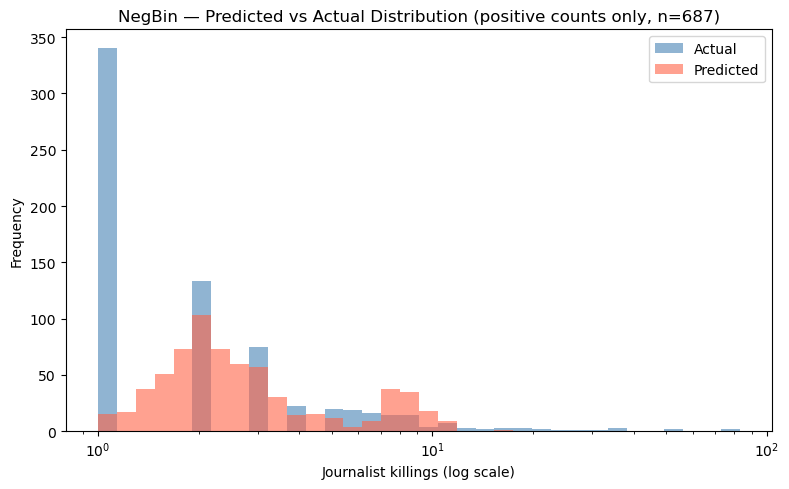

Saved: outputs/results/nb16_predicted_vs_actual.png


In [25]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    roc_auc_score, classification_report, confusion_matrix
)

# ── Logistic component ──────────────────────────────────────────────────────
logit_pred_prob = logit_result.predict(X_logit)
logit_pred_label = (logit_pred_prob >= 0.5).astype(int)
y_true_logit = model_df['killing_any']

logit_auc = roc_auc_score(y_true_logit, logit_pred_prob)

print('=== Logistic component ===')
print(f'  AIC: {logit_result.aic:.2f}   BIC: {logit_result.bic:.2f}')
print(f'  McFadden pseudo-R2: {logit_result.prsquared:.4f}')
print(f'  ROC-AUC: {logit_auc:.4f}')
print()
print('  Classification report (threshold = 0.5):')
print(classification_report(y_true_logit, logit_pred_label,
                            target_names=['zero', 'nonzero'], digits=3))
print('  Confusion matrix (rows=actual, cols=predicted):')
print(confusion_matrix(y_true_logit, logit_pred_label))

# ── NegBin component ────────────────────────────────────────────────────────
nb_pred = nb_result.predict(X_nb)
y_true_nb = positive_df[outcome]

nb_mae = np.abs(y_true_nb - nb_pred).mean()
nb_rmse = np.sqrt(((y_true_nb - nb_pred) ** 2).mean())

print()
print('=== NegBin component (positive counts only) ===')
print(f'  AIC: {nb_result.aic:.2f}   BIC: {nb_result.bic:.2f}')
print(f'  Pseudo-R2: {nb_result.prsquared:.4f}')
print(f'  Alpha (overdispersion): {nb_result.params["alpha"]:.4f}')
print(f'  MAE: {nb_mae:.4f}')
print(f'  RMSE: {nb_rmse:.4f}')

# ── Predicted vs actual plot ─────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
max_val = max(float(y_true_nb.max()), float(nb_pred.max()))
bins = np.logspace(0, np.log10(max_val + 1), 35)
ax.hist(y_true_nb, bins=bins, alpha=0.6, label='Actual', color='steelblue')
ax.hist(nb_pred, bins=bins, alpha=0.6, label='Predicted', color='tomato')
ax.set_xscale('log')
ax.set_xlabel('Journalist killings (log scale)')
ax.set_ylabel('Frequency')
ax.set_title('NegBin — Predicted vs Actual Distribution (positive counts only, n=687)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'nb16_predicted_vs_actual.png', dpi=150)
plt.show()
print('Saved: outputs/results/nb16_predicted_vs_actual.png')

## Part F — Key Findings Summary

In [26]:
# Recompute AUC here so this cell can run standalone
_logit_auc = roc_auc_score(model_df['killing_any'], logit_result.predict(X_logit))

_sig_logit = [
    r for r in logit_table.itertuples()
    if r.term not in ('const',) and r.p_value < 0.05
]
_sig_nb = [
    r for r in nb_table.itertuples()
    if r.term not in ('const', 'alpha') and r.p_value < 0.05
]

print('=' * 70)
print('NOTEBOOK 16 — BASELINE HURDLE MODEL: KEY FINDINGS')
print('=' * 70)

print('\nSAMPLE')
print('  Full panel:       6,358 rows x 38 columns')
print('  After dropna:     5,765 rows  (593 dropped, 9.3%)')
print('  Zero rows:        5,078  (88.1% of model sample)')
print('  Non-zero rows:      687  (11.9% of model sample)')

print('\nZERO COMPONENT — Logistic regression (n = 5,765)')
print(f'  McFadden pseudo-R2 : {logit_result.prsquared:.4f}')
print(f'  ROC-AUC            : {_logit_auc:.4f}')
print(f'  AIC / BIC          : {logit_result.aic:.1f} / {logit_result.bic:.1f}')
print('  Significant predictors (p < 0.05):')
for r in _sig_logit:
    direction = '+' if r.coef > 0 else '-'
    print(f'    {direction} {r.term:<35} coef={r.coef:+.3f}  p={r.p_value:.2e}  {r.significance}')

print('\nCOUNT COMPONENT — Negative Binomial on positives (n = 687)')
print(f'  Pseudo-R2          : {nb_result.prsquared:.4f}')
print(f'  AIC / BIC          : {nb_result.aic:.1f} / {nb_result.bic:.1f}')
print(f'  Alpha (overdispersion): {nb_result.params["alpha"]:.4f} (p<0.001) — hurdle justified')
print('  Significant predictors (p < 0.05):')
for r in _sig_nb:
    direction = '+' if r.coef > 0 else '-'
    print(f'    {direction} {r.term:<35} coef={r.coef:+.3f}  p={r.p_value:.2e}  {r.significance}')

print('\nKEY FLAGS FOR WRITE-UP')
print('  [NULL]    econ_neocol_score_total_lag1: p=0.167 (logit), p=0.051 (NegBin)')
print('            Core theoretical variable shows no significant baseline effect.')
print('  [SIGN]    arms_tiv_total_log_lag1: negative in both models (logit p=0.004,')
print('            NegBin p=0.116). Higher lagged arms -> lower/no killing.')
print('  [CONFOUND] ODA in NegBin: p=0.014 full sample -> p=0.800 excl. IRQ/SYR.')
print('             Count-component ODA effect is entirely crisis-driven.')
print('  [COLLIN]  armed_conflict + conflict_intensity VIF ~8. See Part D for')
print('            stability check with armed_conflict dropped.')
print('  [SE]      Nonrobust SEs underestimate uncertainty for panel data.')
print('            Clustered SEs (Part C) supersede nonrobust results for inference.')
print('=' * 70)

NOTEBOOK 16 — BASELINE HURDLE MODEL: KEY FINDINGS

SAMPLE
  Full panel:       6,358 rows x 38 columns
  After dropna:     5,765 rows  (593 dropped, 9.3%)
  Zero rows:        5,078  (88.1% of model sample)
  Non-zero rows:      687  (11.9% of model sample)

ZERO COMPONENT — Logistic regression (n = 5,765)
  McFadden pseudo-R2 : 0.2689
  ROC-AUC            : 0.8488
  AIC / BIC          : 3097.2 / 3157.1
  Significant predictors (p < 0.05):
    - arms_tiv_total_log_lag1             coef=-0.079  p=3.83e-03  **
    + oda_total_log_lag1                  coef=+0.182  p=2.62e-09  ***
    + colonial_tie_flag                   coef=+0.488  p=3.05e-05  ***
    + gdp_per_capita_log                  coef=+0.215  p=8.16e-06  ***
    + population_log                      coef=+0.552  p=2.29e-41  ***
    - armed_conflict                      coef=-0.475  p=4.66e-02  *
    + conflict_intensity                  coef=+1.542  p=2.93e-19  ***

COUNT COMPONENT — Negative Binomial on positives (n = 687)
  Ps

## Part G — Save Outputs for Report

In [ ]:
OUTPUTS_METHODS = Path('..') / 'outputs' / 'data&methods'
OUTPUTS_RESULTS = Path('..') / 'outputs' / 'results'
OUTPUTS_LIMITS  = Path('..') / 'outputs' / 'limitations'

OUTPUTS_METHODS.mkdir(parents=True, exist_ok=True)
OUTPUTS_RESULTS.mkdir(parents=True, exist_ok=True)
OUTPUTS_LIMITS.mkdir(parents=True, exist_ok=True)

print('Output directories ready.')
print(f'  {OUTPUTS_METHODS}')
print(f'  {OUTPUTS_RESULTS}')
print(f'  {OUTPUTS_LIMITS}')

### G1 — Coefficient Forest Plot (both hurdle components)

95% CI bars use clustered standard errors. Dots coloured by significance level.

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

LABEL_MAP = {
    'arms_tiv_total_log_lag1':      'Arms transfers (lag 1)',
    'oda_total_log_lag1':           'ODA (lag 1)',
    'econ_neocol_score_total_lag1': 'Econ neo-col score (lag 1)',
    'colonial_tie_flag':            'Colonial tie',
    'gdp_per_capita_log':           'GDP per capita (log)',
    'population_log':               'Population (log)',
    'armed_conflict':               'Armed conflict',
    'conflict_intensity':           'Conflict intensity',
}

def dot_color(p):
    if p < 0.01:  return '#1a7a1a'
    if p < 0.05:  return '#6ab04c'
    return '#999999'

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

panels = [
    (axes[0], logit_clustered, 'Zero component (logistic, n=5,765)'),
    (axes[1], nb_clustered,    'Count component (NegBin, n=687)'),
]
for ax, result, subtitle in panels:
    n = len(baseline_features)
    for idx, feat in enumerate(baseline_features):
        yi = n - 1 - idx
        coef = result.params.get(feat, np.nan)
        se   = result.bse.get(feat, np.nan)
        pval = result.pvalues.get(feat, np.nan)
        if np.isnan(coef):
            continue
        lo, hi = coef - 1.96 * se, coef + 1.96 * se
        color = dot_color(pval)
        ax.plot([lo, hi], [yi, yi], color=color, linewidth=1.5, zorder=2)
        ax.scatter([coef], [yi], color=color, s=70, zorder=3)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', zorder=1)
    ax.set_yticks(range(n))
    ax.set_yticklabels(
        [LABEL_MAP.get(f, f) for f in reversed(baseline_features)]
    )
    ax.set_ylim(-0.6, n - 0.4)
    ax.set_xlabel('Coefficient (95% CI)')
    ax.set_title(subtitle, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False)

legend_patches = [
    mpatches.Patch(color='#1a7a1a', label='p < 0.01'),
    mpatches.Patch(color='#6ab04c', label='p < 0.05'),
    mpatches.Patch(color='#999999', label='p ≥ 0.05'),
]
fig.legend(handles=legend_patches, loc='lower center', ncol=3,
           frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.01))
fig.suptitle(
    'Baseline Hurdle Model — Coefficient Estimates (clustered SEs)',
    fontsize=13, fontweight='bold'
)
fig.text(0.5, 0.94,
    'Left: Zero component (logistic). Right: Count component (negative binomial, non-zero rows only)',
    ha='center', fontsize=8, color='#555555')

plt.tight_layout(rect=[0, 0.06, 1, 0.93])
fig.savefig(OUTPUTS_RESULTS / 'nb16_coefficient_forest.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/results/nb16_coefficient_forest.png')

### G2 — ROC Curve

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

roc_pred = logit_clustered.predict(X_logit)
fpr, tpr, _ = roc_curve(model_df['killing_any'], roc_pred)
_auc = roc_auc_score(model_df['killing_any'], roc_pred)

fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, color='steelblue', linewidth=2, label=f'AUC = {_auc:.4f}')
ax.fill_between(fpr, tpr, alpha=0.12, color='steelblue')
ax.plot([0, 1], [0, 1], color='#aaaaaa', linewidth=1,
        linestyle='--', label='Random classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Zero Component (Logistic, clustered SEs)')
ax.legend(loc='lower right', frameon=False)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
fig.savefig(OUTPUTS_RESULTS / 'nb16_roc_curve.png', dpi=150)
plt.show()
print('Saved: outputs/results/nb16_roc_curve.png')

### G3 — ODA Sensitivity Plot

Values drawn from the IRQ/SYR sensitivity analysis already computed in the notebook.

In [ ]:
# Pull values from oda_sensitivity (computed in the IRQ/SYR cell)
def _oda_val(model_name, sample_name):
    row = oda_sensitivity.loc[
        (oda_sensitivity['model'] == model_name) &
        (oda_sensitivity['sample'] == sample_name)
    ]
    if row.empty:
        return np.nan, np.nan
    return float(row['oda_coef'].iloc[0]), float(row['oda_p_value'].iloc[0])

grid_data = [
    [_oda_val('logit_any_killing',               'all_baseline_rows'),
     _oda_val('logit_any_killing',               'excluding_irq_syr')],
    [_oda_val('negative_binomial_positive_counts','all_positive_rows'),
     _oda_val('negative_binomial_positive_counts','excluding_irq_syr')],
]
row_labels = ['Logit (zero component)', 'NegBin (count component)']
col_labels = ['Full sample', 'Excl. Iraq + Syria']

fig, axes = plt.subplots(2, 2, figsize=(9, 4))
fig.suptitle('ODA Coefficient Sensitivity — Iraq & Syria Exclusion Test',
             fontsize=12, fontweight='bold', y=1.03)

for ri in range(2):
    for ci in range(2):
        ax = axes[ri, ci]
        coef, pval = grid_data[ri][ci]
        sig = add_significance(pval)
        sig_label = sig if sig else 'ns'
        is_sig = pval < 0.05
        bg  = '#d4edda' if is_sig else '#f8d7da'
        fg  = '#155724' if is_sig else '#721c24'

        ax.set_facecolor(bg)
        ax.text(0.5, 0.58, f'coef = {coef:.4f}',
                ha='center', va='center', fontsize=13,
                fontweight='bold', color=fg, transform=ax.transAxes)
        ax.text(0.5, 0.28, f'p = {pval:.3f}  {sig_label}',
                ha='center', va='center', fontsize=10,
                color=fg, transform=ax.transAxes)
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_color('#cccccc')

        if ri == 0:
            ax.set_title(col_labels[ci], fontsize=10, pad=8)
        if ci == 0:
            ax.set_ylabel(row_labels[ri], fontsize=9, labelpad=10)

plt.tight_layout()
fig.savefig(OUTPUTS_LIMITS / 'nb16_oda_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/limitations/nb16_oda_sensitivity.png')

### G4 — Clustered vs Nonrobust SE Comparison

Red connecting line = significance bracket changed after clustering. Hollow dot = nonrobust 95% CI. Filled dot = clustered 95% CI. Point estimates are identical in both (only SEs differ).

In [ ]:
from matplotlib.lines import Line2D

LABEL_MAP = {
    'arms_tiv_total_log_lag1':      'Arms transfers (lag 1)',
    'oda_total_log_lag1':           'ODA (lag 1)',
    'econ_neocol_score_total_lag1': 'Econ neo-col score (lag 1)',
    'colonial_tie_flag':            'Colonial tie',
    'gdp_per_capita_log':           'GDP per capita (log)',
    'population_log':               'Population (log)',
    'armed_conflict':               'Armed conflict',
    'conflict_intensity':           'Conflict intensity',
}

fig, axes = plt.subplots(1, 2, figsize=(12, 6), sharey=True)

for ax, se_cmp, title in [
    (axes[0], logit_se_cmp, 'Logit (zero component)'),
    (axes[1], nb_se_cmp,    'NegBin (count component)'),
]:
    preds = se_cmp[~se_cmp['term'].isin(['const', 'alpha'])].reset_index(drop=True)
    n = len(preds)

    for idx, row in preds.iterrows():
        yi = n - 1 - idx
        coef     = row['coef']
        se_nr    = row['se_nonrobust']
        se_cl    = row['se_clustered']
        changed  = row['sig_changed']
        line_col = '#d9534f' if changed else '#cccccc'

        y_nr, y_cl = yi + 0.18, yi - 0.18

        # Nonrobust CI (hollow dot)
        lo_nr, hi_nr = coef - 1.96 * se_nr, coef + 1.96 * se_nr
        ax.plot([lo_nr, hi_nr], [y_nr, y_nr], color='#aaaaaa', linewidth=1, zorder=2)
        ax.scatter([coef], [y_nr], facecolors='none', edgecolors='#555555',
                   s=55, linewidths=1.3, zorder=3)

        # Clustered CI (filled dot)
        lo_cl, hi_cl = coef - 1.96 * se_cl, coef + 1.96 * se_cl
        ax.plot([lo_cl, hi_cl], [y_cl, y_cl], color='#aaaaaa', linewidth=1, zorder=2)
        ax.scatter([coef], [y_cl], facecolors='#333333', edgecolors='#333333',
                   s=55, zorder=3)

        # Connecting line between the two dots
        ax.plot([coef, coef], [y_nr, y_cl], color=line_col, linewidth=1.3, zorder=1)

    ax.axvline(0, color='black', linewidth=0.8, linestyle='--', zorder=0)
    ax.set_yticks(range(n))
    ax.set_yticklabels(
        [LABEL_MAP.get(t, t) for t in reversed(preds['term'].tolist())]
    )
    ax.set_ylim(-0.6, n - 0.4)
    ax.set_xlabel('Coefficient (95% CI)')
    ax.set_title(title, fontsize=10)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.tick_params(left=False)

legend_elements = [
    Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
           markeredgecolor='#555555', markersize=8, label='Nonrobust SE'),
    Line2D([0], [0], marker='o', color='w', markerfacecolor='#333333',
           markeredgecolor='#333333', markersize=8, label='Clustered SE'),
    Line2D([0], [0], color='#d9534f', linewidth=2, label='Significance changed'),
    Line2D([0], [0], color='#cccccc', linewidth=2, label='No change'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=4,
           frameon=False, fontsize=9, bbox_to_anchor=(0.5, -0.03))
fig.suptitle('Effect of Clustering Standard Errors on Coefficient Estimates',
             fontsize=12, fontweight='bold')

plt.tight_layout(rect=[0, 0.07, 1, 1])
fig.savefig(OUTPUTS_LIMITS / 'nb16_clustered_vs_nonrobust.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: outputs/limitations/nb16_clustered_vs_nonrobust.png')

### G5 — Sample Construction & VIF Table (data&methods)

In [ ]:
# 1. Sample construction table
sample_construction = pd.DataFrame([
    {'stage': 'Panel rows (before dropna)',    'n': 6358,  'pct': 100.0},
    {'stage': 'After dropna (model sample)',   'n': 5765,  'pct': 90.7},
    {'stage': 'Dropped rows',                  'n': 593,   'pct': 9.3},
    {'stage': 'Zero killing rows (logit denom)','n': 5078,  'pct': 88.1},
    {'stage': 'Non-zero killing rows (NegBin)', 'n': 687,   'pct': 11.9},
])
out_sc = OUTPUTS_METHODS / 'sample_construction_nb16.csv'
sample_construction.to_csv(out_sc, index=False)
print(f'Saved: {out_sc}')
display(sample_construction)

# 2. VIF table (re-save with clear filename)
out_vif = OUTPUTS_METHODS / 'vif_table_nb16.csv'
vif_table.to_csv(out_vif, index=False)
print(f'Saved: {out_vif}')
display(vif_table)